<a href="https://colab.research.google.com/github/Shrishti061997/Human_Factors_Engineering/blob/ANOVA/ANOVA_HFE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**📊 Scenario**

A human factors researcher is investigating how display characteristics affect a user’s ability to quickly perform a visual search task on a digital display.

**Two independent variables**

1. Screen Size (Factor A – 2 levels)

* Small

* Large

2. Screen Brightness (Factor B – 3 levels)

* Low

* Medium

* High

**Dependent Variable**

* Task Performance Time (ms): The time (in milliseconds) it took each participant to correctly complete the visual search.

* Each participant performed the task once, and each participant was randomly assigned to one of the six experimental conditions. There were 10 participants per cell, giving a total of 60 participants.

The dataset:

📁 DATA-HFE.csv

In [ ]:


import numpy as np
import pandas as pd

# Install statsmodels if not already installed
!pip install statsmodels scipy -q

import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats


In [3]:
df = pd.read_csv("DATA-HFE.csv")   # make sure the filename matches exactly
print(df.head())
print(df.dtypes)

   Subject   Size Brightness  Perf_ms
0        1  Small        Low   522.86
1        2  Small        Low   517.67
2        3  Small        Low   566.48
3        4  Small        Low   567.80
4        5  Small        Low   551.53
Subject         int64
Size           object
Brightness     object
Perf_ms       float64
dtype: object


In [4]:
# descriptive stats and cell means

print("Overall N:", len(df))
print("Overall mean performance (ms):", df["Perf_ms"].mean())

# Convert to categorical explicitly
df["Size"] = df["Size"].astype("category")
df["Brightness"] = df["Brightness"].astype("category")

# Cell means for the 2x3 design
cell_means = df.groupby(["Size", "Brightness"])["Perf_ms"].mean().unstack()
print("\nCell means (Perf_ms):")
print(cell_means)

# Marginal means
size_means = df.groupby("Size")["Perf_ms"].mean()
bright_means = df.groupby("Brightness")["Perf_ms"].mean()

print("\nMarginal means for Size:")
print(size_means)

print("\nMarginal means for Brightness:")
print(bright_means)


Overall N: 60
Overall mean performance (ms): 528.251

Cell means (Perf_ms):
Brightness     High      Low      Med
Size                                 
Large       525.787  535.523  503.876
Small       545.384  544.603  514.333

Marginal means for Size:
Size
Large    521.728667
Small    534.773333
Name: Perf_ms, dtype: float64

Marginal means for Brightness:
Brightness
High    535.5855
Low     540.0630
Med     509.1045
Name: Perf_ms, dtype: float64


/tmp/ipython-input-3381171034.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_means = df.groupby(["Size", "Brightness"])["Perf_ms"].mean().unstack()
/tmp/ipython-input-3381171034.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_means = df.groupby("Size")["Perf_ms"].mean()
/tmp/ipython-input-3381171034.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bright_means = df.groupby("Brightness")["Perf_ms"

In [5]:
#two-way ANOVA using statsmodels

model = ols("Perf_ms ~ Size * Brightness", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)  # Type II ANOVA
print(anova_table)


                       sum_sq    df          F        PR(>F)
Size              2552.449927   1.0   8.455028  5.272628e-03
Brightness       11198.133930   2.0  18.546991  7.386012e-07
Size:Brightness    326.738363   2.0   0.541163  5.851946e-01
Residual         16301.815120  54.0        NaN           NaN


Size:

F(1, 54) ≈ 8.46, p ≈ .0053

Brightness:

F(2, 54) ≈ 18.55, p ≈ 7.39×10⁻⁷

Size × Brightness:

F(2, 54) ≈ 0.54, p ≈ .585

**Interpretation**

* Main effect of Screen Size is significant: Participants are slower on Small screens than on Large screens.

* Main effect of Brightness is significant: Performance depends strongly on brightness. Medium brightness is associated with faster responses than Low or High.

* Size × Brightness interaction is NOT significant: The effect of brightness is roughly similar for both screen sizes; no strong evidence that brightness works differently on small vs large screens in this dataset.

Cell means used for interaction plot:


/tmp/ipython-input-4230414987.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Brightness", "Size"])["Perf_ms"]


Size,Large,Small
Brightness,,
High,525.787,545.384
Low,535.523,544.603
Med,503.876,514.333


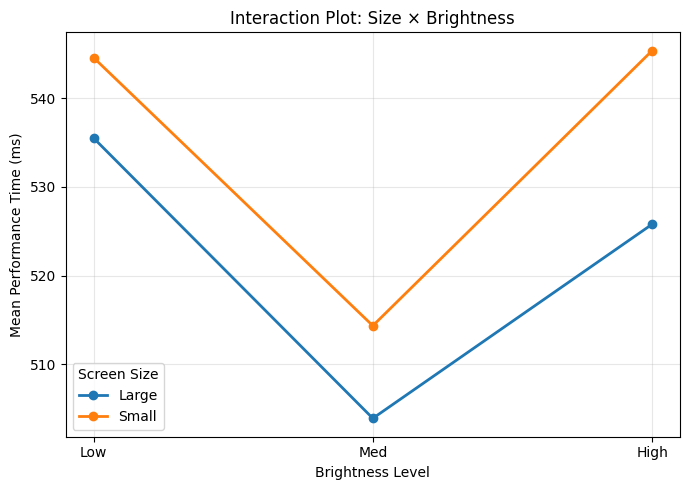

In [6]:

# Interaction Plot for Size × Brightness


import matplotlib.pyplot as plt
import pandas as pd

# the means for each Brightness × Size combination
means_interaction = (
    df.groupby(["Brightness", "Size"])["Perf_ms"]
      .mean()
      .unstack()
)

print("Cell means used for interaction plot:")
display(means_interaction)

# Ensure Brightness is ordered logically (Low, then Med, then High)
brightness_order = ["Low", "Med", "High"]
means_interaction = means_interaction.reindex(brightness_order)

# Plot
plt.figure(figsize=(7, 5))

for size_level in means_interaction.columns:
    plt.plot(
        means_interaction.index,
        means_interaction[size_level],
        marker="o",
        linewidth=2,
        label=size_level
    )

plt.xlabel("Brightness Level")
plt.ylabel("Mean Performance Time (ms)")
plt.title("Interaction Plot: Size × Brightness")
plt.grid(True, alpha=0.3)
plt.legend(title="Screen Size")
plt.tight_layout()
plt.show()


The **interaction plot** illustrates how screen brightness affects task performance (Perf_ms) separately for Small and Large screen sizes. The x-axis represents the three brightness levels (Low, Medium, High), and the y-axis shows the mean task completion time in milliseconds. Two lines—one for Small screens and one for Large screens—show the pattern of how performance changes across brightness conditions for each screen size.

Across all brightness levels, the Small screen consistently produces higher performance times (i.e., slower performance) compared to the Large screen, indicating a main effect of screen size. The slope of the lines across brightness levels is similar for both screen sizes: performance is worst at Low brightness, best at Medium brightness, and becomes somewhat slower again at High brightness. Because these lines follow the same general pattern and remain roughly parallel, there is little evidence of an interaction between Size and Brightness. This visual pattern supports the ANOVA results, which found strong main effects of Size and Brightness but no significant interaction.

**Overall, the plot shows that:**

* Medium brightness yields the fastest performance, regardless of screen size.

* Small screens lead to slower performance overall.

* The effect of brightness is similar for both screen sizes, indicating no meaningful interaction.